# Dividend Investing Algorithm

A quantitative dividend stock screener that identifies the **top 10 income-generating securities** from the S&P 500. Stocks are scored using a weighted normalisation model across five dividend metrics, balancing current yield against sustainability and growth.

**Metrics:** Dividend Yield, Dividend Rate, Payout Ratio, 5-Year Average Yield, Earnings Growth  
**Method:** Min-max normalisation with custom weighting (payout ratio inverse-scored)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
from scipy import stats
import matplotlib.pyplot as plt

## 2. Load Stock Universe

In [2]:
tickers = pd.read_csv("sp500_stocks.csv")
print(f"Loaded {len(tickers)} stocks across {tickers['Sector'].nunique()} sectors")
tickers.head()

Loaded 50 stocks across 9 sectors


,Ticker,Company Name,Sector
0,AAPL,Apple Inc.,Technology
1,MSFT,Microsoft Corporation,Technology
2,GOOGL,Alphabet Inc.,Technology
3,AMZN,Amazon.com Inc.,Technology
4,NVDA,NVIDIA Corporation,Technology


## 3. Fetch Dividend Data

For each stock, retrieve five dividend-related metrics:

| Metric | Weight | Direction | Rationale |
|--------|--------|-----------|----------|
| **Dividend Yield** | 30% | Higher is better | Current income return |
| **Dividend Rate** | 20% | Higher is better | Absolute dollar payout |
| **Payout Ratio** | 20% | Lower is better | Sustainability — lower means more room to maintain dividends |
| **5-Year Avg Yield** | 20% | Higher is better | Consistency of income over time |
| **Earnings Growth** | 10% | Higher is better | Future dividend growth potential |

In [3]:
def create_dividend_df(tickers):
    columns = [
        "Ticker", "Dividend Yield (%)", "Dividend Rate",
        "Payout Ratio (%)", "5Y Avg Yield (%)", "Earnings Growth (%)"
    ]
    dividend_df = pd.DataFrame(columns=columns)

    for stock in tickers:
        info = yf.Ticker(stock).info

        dividend_yield = info.get('dividendYield', np.nan) * 100 if info.get('dividendYield') else np.nan
        dividend_rate = info.get("dividendRate", np.nan)
        payout_ratio = info.get("payoutRatio", np.nan) * 100 if info.get("payoutRatio") else np.nan
        five_yr_avg = info.get("fiveYearAvgDividendYield", np.nan)
        earning_growth = info.get("earningsGrowth", np.nan) * 100 if info.get("earningsGrowth") else np.nan

        dividend_df.loc[len(dividend_df)] = [
            stock, dividend_yield, dividend_rate, payout_ratio, five_yr_avg, earning_growth
        ]

    return dividend_df

tickers_list = tickers["Ticker"].values.tolist()
dividend_df = create_dividend_df(tickers_list)
print(f"Fetched dividend data for {len(dividend_df)} stocks")
dividend_df.head()

Fetched dividend data for 50 stocks


,Ticker,Dividend Yield (%),Dividend Rate,Payout Ratio (%),5Y Avg Yield (%),Earnings Growth (%)
0,AAPL,38.0,1.08,12.590000,0.50,21.8
1,MSFT,98.0,3.64,20.729999,0.79,23.4
2,GOOGL,26.0,0.88,6.410000,NaN,82.0
3,AMZN,NaN,NaN,NaN,NaN,74.8
4,NVDA,52.0,1.00,0.610000,0.05,214.5


## 4. Handle Missing Values

In [4]:
numeric_cols = [
    "Dividend Yield (%)", "Dividend Rate", "Payout Ratio (%)",
    "5Y Avg Yield (%)", "Earnings Growth (%)"
]

for column in numeric_cols:
    dividend_df[column] = pd.to_numeric(dividend_df[column], errors='coerce')
    dividend_df[column] = dividend_df[column].fillna(dividend_df[column].mean())

print(f"Missing values after cleaning: {dividend_df[numeric_cols].isna().sum().sum()}")

Missing values after cleaning: 0


## 5. Normalisation & Weighted Scoring

Each metric is min-max normalised to a 0-1 scale. **Payout ratio is inverse-normalised** (lower payout = higher score, indicating greater sustainability). The weighted sum produces a final dividend score.

In [5]:
for col in numeric_cols:
    col_min = dividend_df[col].min()
    col_max = dividend_df[col].max()
    if col == "Payout Ratio (%)":
        dividend_df[col + " Norm"] = 1 - (dividend_df[col] - col_min) / (col_max - col_min)
    else:
        dividend_df[col + " Norm"] = (dividend_df[col] - col_min) / (col_max - col_min)

weights = {
    "Dividend Yield (%) Norm": 0.30,
    "Dividend Rate Norm": 0.20,
    "Payout Ratio (%) Norm": 0.20,
    "5Y Avg Yield (%) Norm": 0.20,
    "Earnings Growth (%) Norm": 0.10
}

dividend_df["Dividend Score"] = (
    dividend_df[[col for col in weights.keys()]]
    .mul(list(weights.values()))
    .sum(axis=1)
)

dividend_df = dividend_df.sort_values(by="Dividend Score", ascending=False)
dividend_df.reset_index(inplace=True, drop=True)

## 6. Top 10 Dividend Stocks

In [6]:
top_10 = dividend_df.head(10).copy()

display_cols = [
    "Ticker", "Dividend Yield (%)", "Dividend Rate",
    "Payout Ratio (%)", "5Y Avg Yield (%)",
    "Earnings Growth (%)", "Dividend Score"
]
top_10[display_cols].round(2)

,Ticker,Dividend Yield (%),Dividend Rate,Payout Ratio (%),5Y Avg Yield (%),Earnings Growth (%),Dividend Score
0,PFE,708.0,1.72,131.30,5.05,-10.1,0.64
1,UPS,607.0,6.56,106.15,4.34,-27.2,0.62
2,BLK,238.0,22.92,53.76,2.34,45.9,0.59
3,GS,177.0,18.00,28.31,2.20,24.2,0.52
4,CVX,416.0,7.12,120.38,4.03,-44.5,0.52
5,PEP,419.0,5.92,89.32,3.03,27.8,0.51
6,LMT,272.0,13.80,65.38,2.63,-11.5,0.50
7,DUK,332.0,4.26,65.23,3.83,12.0,0.50
8,NEE,281.0,2.49,58.95,2.50,160.0,0.47
9,SO,313.0,3.04,75.70,3.64,-0.8,0.46


## 7. Visualisation

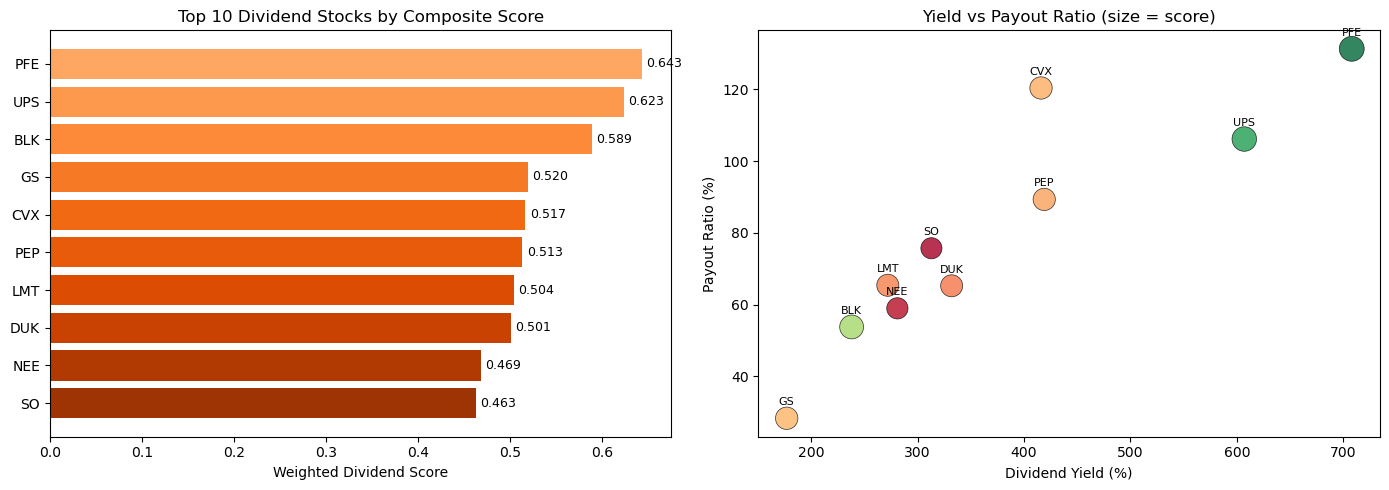

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_10)))

# Dividend score ranking
axes[0].barh(top_10["Ticker"], top_10["Dividend Score"], color=colors)
axes[0].set_xlabel("Weighted Dividend Score")
axes[0].set_title("Top 10 Dividend Stocks by Composite Score")
axes[0].invert_yaxis()
for i, v in enumerate(top_10["Dividend Score"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

# Yield vs Payout scatter
sc = axes[1].scatter(
    top_10["Dividend Yield (%)"],
    top_10["Payout Ratio (%)"],
    s=top_10["Dividend Score"] * 500,
    c=top_10["Dividend Score"],
    cmap="RdYlGn", edgecolors="black", linewidth=0.5, alpha=0.8
)
for i, ticker in enumerate(top_10["Ticker"]):
    axes[1].annotate(ticker, (top_10["Dividend Yield (%)"].iloc[i],
                              top_10["Payout Ratio (%)"].iloc[i]),
                     fontsize=8, ha="center", va="bottom", xytext=(0, 8),
                     textcoords="offset points")
axes[1].set_xlabel("Dividend Yield (%)")
axes[1].set_ylabel("Payout Ratio (%)")
axes[1].set_title("Yield vs Payout Ratio (size = score)")

plt.tight_layout()
plt.savefig("dividend_investing_results.png", dpi=150, bbox_inches="tight")
plt.show()